Dataset shape: (125973, 43)
Missing values: 0

Top 10 labels:
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

Class distribution:
target
Normal    67343
Attack    58630
Name: count, dtype: int64

Training samples: 100778
Testing samples : 25195

Model trained successfully!

Accuracy: 99.86 %

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



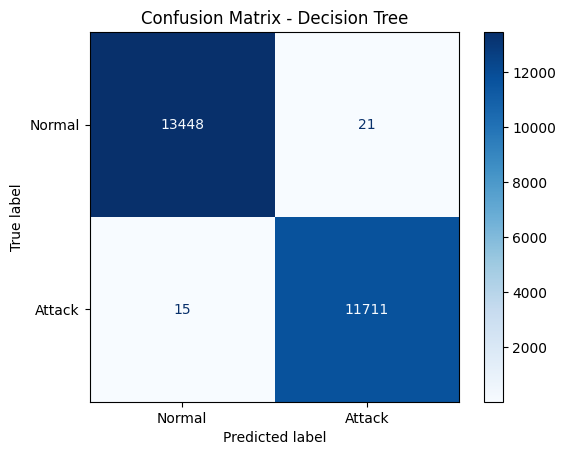

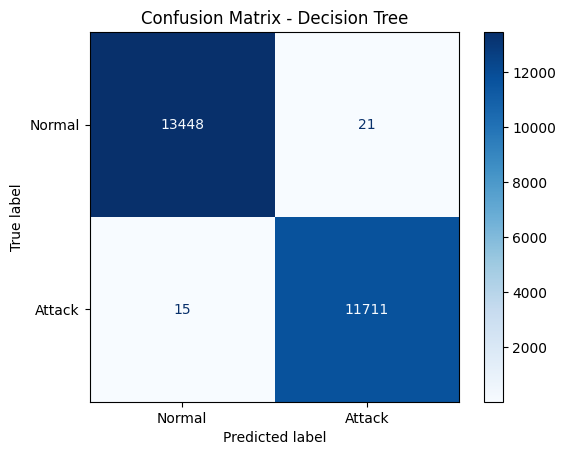

Random Forest trained!
Logistic Regression trained!
Model Comparison (Precision/Recall/F1 are for the Attack class):


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,0.9990,0.9995,0.9985,0.9990
Decision Tree,0.9986,0.9982,0.9987,0.9985
Logistic Regression,0.9718,0.9764,0.9627,0.9695


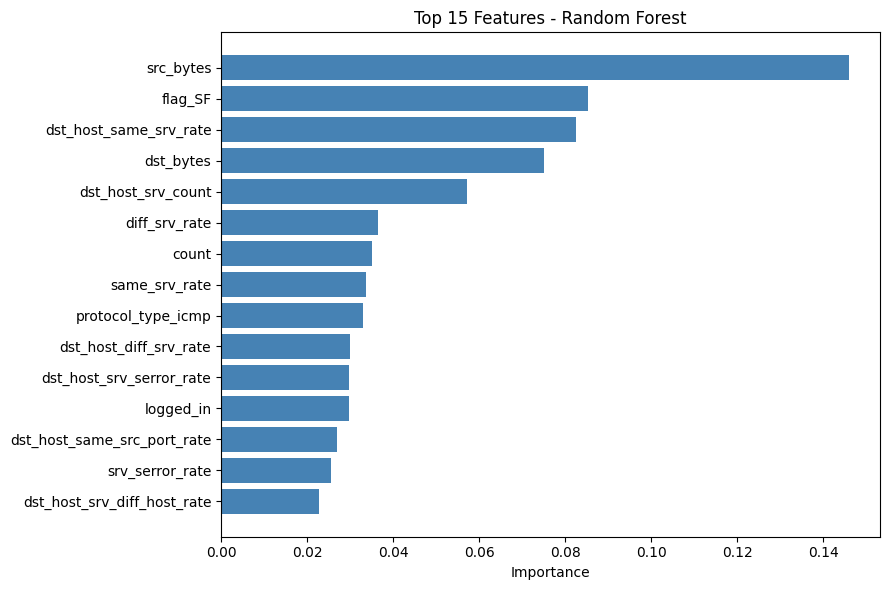

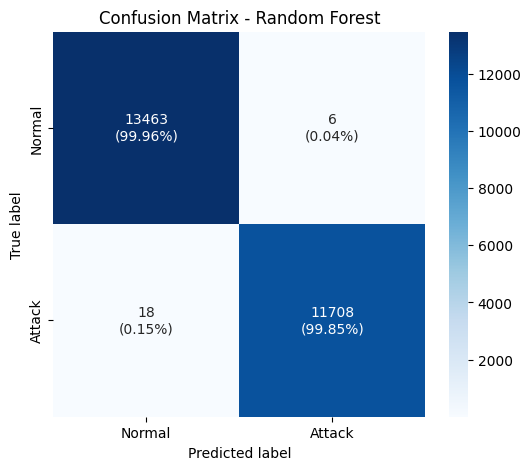

True Negatives  (TN): 13463 -> Normal traffic correctly identified
False Positives (FP): 6 -> Normal traffic wrongly flagged as attack (false alarms)
False Negatives (FN): 18 -> Attacks that were MISSED
True Positives  (TP): 11708 -> Attacks correctly detected
Top 10 most important features (Random Forest):

               Feature  Importance
             src_bytes      0.1459
               flag_SF      0.0853
dst_host_same_srv_rate      0.0825
             dst_bytes      0.0751
    dst_host_srv_count      0.0571
         diff_srv_rate      0.0365
                 count      0.0350
         same_srv_rate      0.0337
    protocol_type_icmp      0.0330
dst_host_diff_srv_rate      0.0299


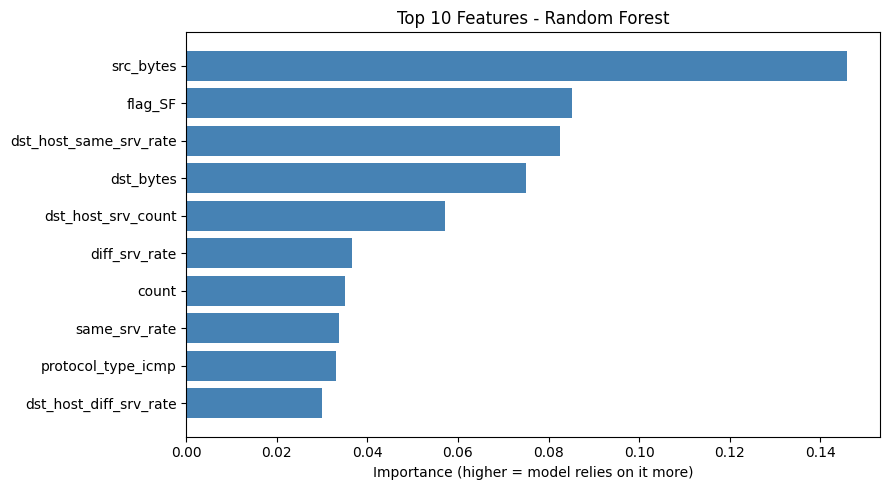


Why the top features matter (where a description is available):
- src_bytes: Bytes sent from source to destination; attack traffic often has unusual payload sizes.
- flag_SF: Normal TCP connection that started and finished properly.
- dst_host_same_srv_rate: Share of the target host's recent connections using the same service.
- dst_bytes: Bytes sent back by the destination; 0 can mean the target never replied.
- dst_host_srv_count: Connections to the same service on the target host (last 100 connections).
- diff_srv_rate: Share of recent connections to different services; high in port scans.
- count: Connections to the same host in the last 2 seconds; high in floods and scans.
- same_srv_rate: Share of recent connections to the same service; floods hit one service repeatedly.
- protocol_type_icmp: ICMP (ping-type) traffic, used in ping floods and some scans.
- dst_host_diff_srv_rate: Share of the target host's recent connections using different services.

Top 10 ORIGINAL features (on

,test_samples,detected,missed,detection_rate,category,total_in_dataset
label,,,,,,
ftp_write,2,0,2,0.0000,R2L,8
spy,1,0,1,0.0000,R2L,2
multihop,4,2,2,0.5000,R2L,7
guess_passwd,13,12,1,0.9231,R2L,53
warezclient,198,193,5,0.9747,R2L,890
pod,41,40,1,0.9756,DoS,201
portsweep,594,589,5,0.9916,Probe,2931
satan,762,761,1,0.9987,Probe,3633
loadmodule,1,1,0,1.0000,U2R,9



Detection rate per attack CATEGORY (weakest first):



,test_samples,detected,missed,detection_rate,share_of_all_missed_attacks
category,,,,,
R2L,226,215,11,0.9513,0.6111
Probe,2389,2383,6,0.9975,0.3333
DoS,9105,9104,1,0.9999,0.0556
U2R,6,6,0,1.0000,0.0000



Normal traffic correctly classified as normal: 0.9996

Weakest attack CATEGORY in our results: R2L (detection rate 95.13%)
Weakest attack TYPE with at least 10 test samples: guess_passwd (detection rate 92.31%)
Attack types with fewer than 10 test samples give UNRELIABLE percentages (one miss changes the rate a lot).

WHY SOME ATTACKS ARE HARDER TO DETECT (check against the tables above):
1. Rare classes: types with very few training samples give the model little to learn from.
2. Content-based attacks (typically R2L and U2R, e.g. password guessing, privilege
   escalation) can look like a normal user session at the traffic-statistics level.
3. DoS and Probe attacks usually leave strong statistical patterns (many connections,
   SYN errors, many ports), so they are usually easier to detect.
Only claim what the tables above actually show for YOUR run.

Demo 1 - real normal connection from the test set
Prediction: Normal Traffic   (attack probability: 0.00%)
Actual label: Normal

Demo 2

Metric,Value
Dataset size (rows used),"125,973"
Training samples,"100,778"
Testing samples,"25,195"
Best model,Random Forest
Best accuracy,99.9047%
Best attack precision,99.9488%
Best attack recall,99.8465%
Best F1-score,99.8976%


Best model is chosen by Attack-class F1-score. Precision, recall and F1 are for the Attack class.


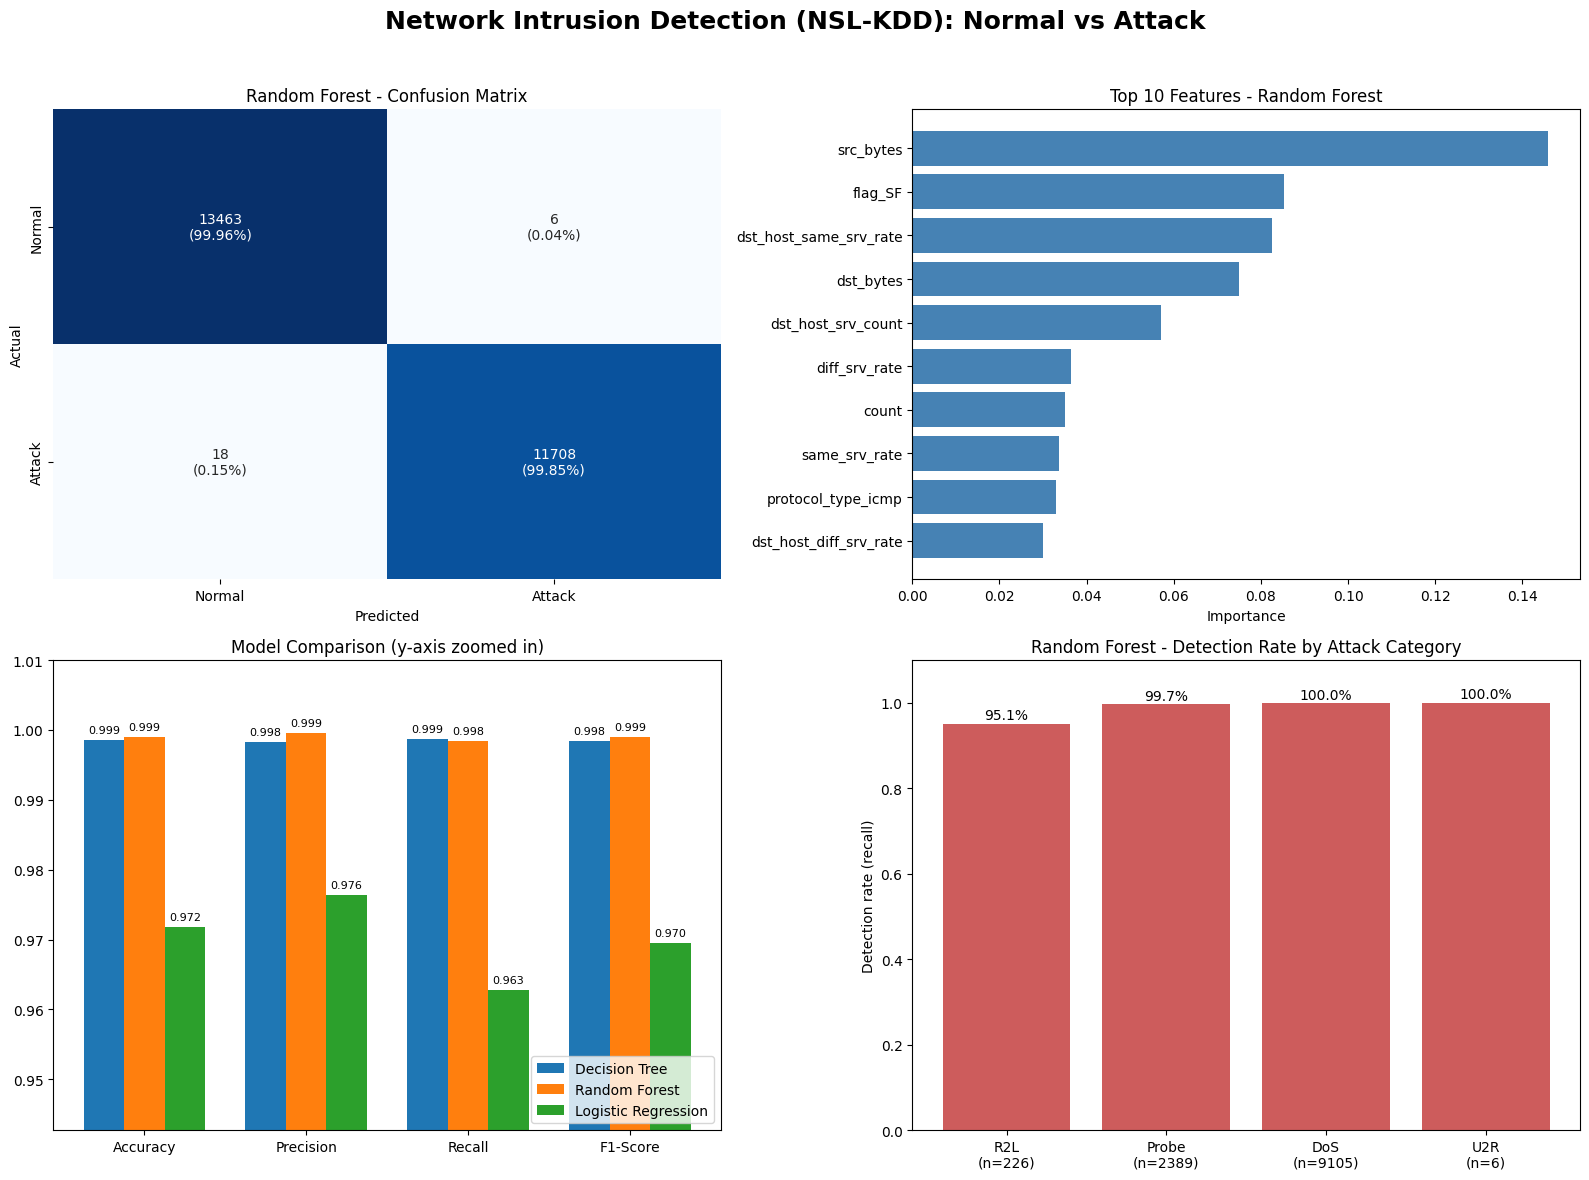

In [1]:
# ==============================================================
# Network Intrusion Detection (Normal vs Attack) - NSL-KDD
# Core ML pipeline: Decision Tree
# ==============================================================

# ---------- STEP 1: Import libraries ----------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# ---------- STEP 2: Load dataset and name the columns ----------
# The NSL-KDD .txt file has NO header row, so we give column names ourselves.
# If this link fails: download KDDTrain+.txt from Kaggle, upload it to Colab
# (left sidebar -> Files) and set DATA_URL = "KDDTrain+.txt"
DATA_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label",        # 'normal' or an attack name (neptune, smurf, ...)
    "difficulty"    # difficulty score (not useful for us, dropped later)
]

df = pd.read_csv(DATA_URL, header=None, names=column_names)

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("\nTop 10 labels:")
print(df["label"].value_counts().head(10))

# ---------- STEP 3: Convert target to binary (Normal vs Attack) ----------
# 0 = Normal, 1 = Attack
df["target"] = df["label"].apply(lambda x: 0 if x == "normal" else 1)

# Drop columns we don't want as input features
df = df.drop(columns=["label", "difficulty"])

print("\nClass distribution:")
print(df["target"].value_counts().rename({0: "Normal", 1: "Attack"}))

# ---------- STEP 4: Split features (X) and target (y), then train/test split ----------
X = df.drop(columns=["target"])   # input features
y = df["target"]                  # what we want to predict

# 80% training, 20% testing; stratify keeps the Normal/Attack ratio equal in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

# ---------- STEP 5: Preprocessing ----------
# Text columns -> numbers using One-Hot Encoding.
# Numeric columns are passed through unchanged (Decision Trees don't need scaling).
categorical_cols = ["protocol_type", "service", "flag"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"   # keep all numeric columns as they are
)

# ---------- STEP 6: Build and train the model ----------
# Pipeline = preprocessing + Decision Tree, applied automatically in order
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

model.fit(X_train, y_train)
print("\nModel trained successfully!")

# ---------- STEP 7: Evaluate the model ----------
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(accuracy * 100, 2), "%")

# Classification report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

# ---------- STEP 8: Confusion matrix ----------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# How to read the confusion matrix:
# Top-left     = Normal traffic correctly identified
# Bottom-right = Attacks correctly caught
# Top-right    = Normal traffic wrongly flagged as attack (false alarm)
# Bottom-left  = Attacks that were MISSED (most dangerous error in security)

# ---------- Decision Tree confusion matrix ----------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

dt_model = model                      # your already-trained Decision Tree pipeline
y_pred_dt = dt_model.predict(X_test)

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=["Normal", "Attack"]).plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# ---------- Train Random Forest and Logistic Regression ----------
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --- Random Forest: same preprocessing as the Decision Tree ---
# clone() makes a fresh copy of the preprocessor so the Decision Tree pipeline stays untouched
rf_model = Pipeline(steps=[
    ("preprocess", clone(preprocessor)),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_model.fit(X_train, y_train)
print("Random Forest trained!")

# --- Logistic Regression ---
# Same one-hot encoding, but numeric columns are also SCALED, because Logistic
# Regression is sensitive to feature size (e.g. src_bytes is huge vs. rates 0-1).
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

lr_preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

lr_model = Pipeline(steps=[
    ("preprocess", lr_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_model.fit(X_train, y_train)
print("Logistic Regression trained!")

# ---------- Compare all three models ----------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Logistic Regression": lr_model
}

results = []
for name, clf in models.items():
    y_pred_m = clf.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, y_pred_m),
        "Precision": precision_score(y_test, y_pred_m),   # for the "Attack" class (1)
        "Recall":    recall_score(y_test, y_pred_m),
        "F1-Score":  f1_score(y_test, y_pred_m)
    })

comparison_df = pd.DataFrame(results).set_index("Model").round(4)
comparison_df = comparison_df.sort_values("F1-Score", ascending=False)

print("Model Comparison (Precision/Recall/F1 are for the Attack class):")
display(comparison_df)
# ---------- Random Forest feature importance ----------
# Get feature names after preprocessing (one-hot columns + numeric columns)
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
feature_names = [n.replace("cat__", "").replace("remainder__", "") for n in feature_names]

importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = (pd.DataFrame({"Feature": feature_names, "Importance": importances})
                   .sort_values("Importance", ascending=False)
                   .head(15))

plt.figure(figsize=(9, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1], color="steelblue")
plt.xlabel("Importance")
plt.title("Top 15 Features - Random Forest")
plt.tight_layout()
plt.show()

# ==========================================================
# CELL 1: Confusion matrix - Random Forest
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

# For binary classification, ravel() gives: TN, FP, FN, TP  (Attack = positive class = 1)
tn, fp, fn, tp = cm.ravel()

# Show counts AND the percentage within each true class (row)
row_totals = cm.sum(axis=1, keepdims=True)
annot = np.array([[f"{cm[i, j]}\n({cm[i, j] / row_totals[i, 0]:.2%})"
                   for j in range(2)] for i in range(2)])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

print("True Negatives  (TN):", tn, "-> Normal traffic correctly identified")
print("False Positives (FP):", fp, "-> Normal traffic wrongly flagged as attack (false alarms)")
print("False Negatives (FN):", fn, "-> Attacks that were MISSED")
print("True Positives  (TP):", tp, "-> Attacks correctly detected")

# ==========================================================
# CELL 2: Random Forest feature importance - Top 10
# ==========================================================
import pandas as pd
import matplotlib.pyplot as plt

# Feature names AFTER preprocessing (one-hot columns + numeric columns)
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
feature_names = [n.replace("cat__", "").replace("remainder__", "") for n in feature_names]

importances = rf_model.named_steps["classifier"].feature_importances_

imp_df = (pd.DataFrame({"Feature": feature_names, "Importance": importances})
            .sort_values("Importance", ascending=False)
            .reset_index(drop=True))

top10 = imp_df.head(10)

print("Top 10 most important features (Random Forest):\n")
print(top10.round(4).to_string(index=False))

# Bar chart
plt.figure(figsize=(9, 5))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="steelblue")
plt.xlabel("Importance (higher = model relies on it more)")
plt.title("Top 10 Features - Random Forest")
plt.tight_layout()
plt.show()

# ---- Simple explanations (general network-security meaning of common features) ----
# Check these against YOUR top-10 output above before presenting.
explanations = {
    "src_bytes": "Bytes sent from source to destination; attack traffic often has unusual payload sizes.",
    "dst_bytes": "Bytes sent back by the destination; 0 can mean the target never replied.",
    "count": "Connections to the same host in the last 2 seconds; high in floods and scans.",
    "srv_count": "Connections to the same service in the last 2 seconds; high in floods.",
    "same_srv_rate": "Share of recent connections to the same service; floods hit one service repeatedly.",
    "diff_srv_rate": "Share of recent connections to different services; high in port scans.",
    "serror_rate": "Share of connections with SYN errors; high in SYN-flood style DoS attacks.",
    "srv_serror_rate": "Same as serror_rate but per service.",
    "logged_in": "1 if login succeeded; many DoS/probe attacks never log in, normal users usually do.",
    "dst_host_srv_count": "Connections to the same service on the target host (last 100 connections).",
    "dst_host_same_srv_rate": "Share of the target host's recent connections using the same service.",
    "dst_host_diff_srv_rate": "Share of the target host's recent connections using different services.",
    "dst_host_serror_rate": "SYN-error rate on the target host; high during SYN floods.",
    "dst_host_srv_serror_rate": "SYN-error rate per service on the target host.",
    "dst_host_count": "Number of recent connections to the target host.",
    "dst_host_same_src_port_rate": "Share of recent connections using the same source port.",
    "flag_SF": "Normal TCP connection that started and finished properly.",
    "flag_S0": "SYN sent but no reply; typical sign of a SYN flood.",
    "protocol_type_icmp": "ICMP (ping-type) traffic, used in ping floods and some scans.",
    "service_private": "Connections to uncommon/private ports; often seen in scans and floods.",
    "service_ecr_i": "ICMP echo reply traffic; seen in ping-based attacks.",
}

print("\nWhy the top features matter (where a description is available):")
for f in top10["Feature"]:
    if f in explanations:
        print(f"- {f}: {explanations[f]}")

# ---- Importance grouped by ORIGINAL feature (adds up one-hot columns) ----
def base_feature(name):
    for prefix in ["protocol_type_", "service_", "flag_"]:
        if name.startswith(prefix):
            return prefix[:-1]
    return name

grouped = (imp_df.assign(Original=imp_df["Feature"].apply(base_feature))
                 .groupby("Original")["Importance"].sum()
                 .sort_values(ascending=False).head(10))
print("\nTop 10 ORIGINAL features (one-hot columns combined):")
print(grouped.round(4).to_string())

# ==========================================================
# CELL 3: Attack-type analysis using ORIGINAL labels
# ==========================================================
import pandas as pd

# Reload the raw file to recover the original labels (we dropped them earlier).
# X_test keeps the original row numbers, so we can look the labels up with .loc
raw = pd.read_csv(DATA_URL, header=None, names=column_names)
test_labels = raw.loc[X_test.index, "label"]

# Standard NSL-KDD grouping of attack names into 4 categories
category_map = {
    # DoS (Denial of Service)
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS",
    "smurf": "DoS", "teardrop": "DoS",
    # Probe (scanning / surveillance)
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe", "satan": "Probe",
    # R2L (Remote to Local - unauthorized access from outside)
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L", "multihop": "R2L",
    "phf": "R2L", "spy": "R2L", "warezclient": "R2L", "warezmaster": "R2L",
    # U2R (User to Root - privilege escalation)
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R", "rootkit": "U2R",
}

# ---- 1) Number of samples per label in the full dataset ----
counts = raw["label"].value_counts()
print("Samples per label in the dataset:\n")
print(counts.to_string())

# ---- 2) Evaluate Random Forest per attack type ----
y_pred_rf = rf_model.predict(X_test)
eval_df = pd.DataFrame({"label": test_labels.values, "pred": y_pred_rf})
eval_df["category"] = eval_df["label"].apply(
    lambda x: "Normal" if x == "normal" else category_map.get(x, "Other"))

attacks = eval_df[eval_df["label"] != "normal"]
total_missed = (attacks["pred"] == 0).sum()

# NOTE: for attack types only RECALL (detection rate) makes sense:
# every sample of an attack type is truly "attack", so we ask "what share did we catch?"
type_table = attacks.groupby("label").agg(
    test_samples=("pred", "size"),
    detected=("pred", "sum"))
type_table["missed"] = type_table["test_samples"] - type_table["detected"]
type_table["detection_rate"] = (type_table["detected"] / type_table["test_samples"]).round(4)
type_table["category"] = [category_map.get(l, "Other") for l in type_table.index]
type_table["total_in_dataset"] = counts.reindex(type_table.index).values
type_table = type_table.sort_values("detection_rate")

print("\n\nDetection rate (recall) per attack TYPE - Random Forest (weakest first):\n")
display(type_table)

cat_table = attacks.groupby("category").agg(
    test_samples=("pred", "size"),
    detected=("pred", "sum"))
cat_table["missed"] = cat_table["test_samples"] - cat_table["detected"]
cat_table["detection_rate"] = (cat_table["detected"] / cat_table["test_samples"]).round(4)
if total_missed > 0:
    cat_table["share_of_all_missed_attacks"] = (cat_table["missed"] / total_missed).round(4)
cat_table = cat_table.sort_values("detection_rate")

print("\nDetection rate per attack CATEGORY (weakest first):\n")
display(cat_table)

normal_rows = eval_df[eval_df["label"] == "normal"]
print(f"\nNormal traffic correctly classified as normal: "
      f"{(normal_rows['pred'] == 0).mean():.4f}")

# ---- 3) Automatic summary of the hardest cases ----
weakest_cat = cat_table["detection_rate"].idxmin()
print(f"\nWeakest attack CATEGORY in our results: {weakest_cat} "
      f"(detection rate {cat_table.loc[weakest_cat, 'detection_rate']:.2%})")

reliable = type_table[type_table["test_samples"] >= 10]
if len(reliable) > 0:
    worst = reliable["detection_rate"].idxmin()
    print(f"Weakest attack TYPE with at least 10 test samples: {worst} "
          f"(detection rate {reliable.loc[worst, 'detection_rate']:.2%})")
print("Attack types with fewer than 10 test samples give UNRELIABLE percentages "
      "(one miss changes the rate a lot).")

print("""
WHY SOME ATTACKS ARE HARDER TO DETECT (check against the tables above):
1. Rare classes: types with very few training samples give the model little to learn from.
2. Content-based attacks (typically R2L and U2R, e.g. password guessing, privilege
   escalation) can look like a normal user session at the traffic-statistics level.
3. DoS and Probe attacks usually leave strong statistical patterns (many connections,
   SYN errors, many ports), so they are usually easier to detect.
Only claim what the tables above actually show for YOUR run.
""")

# ==========================================================
# CELL 4: Simple prediction demo (uses the SAME trained pipeline)
# ==========================================================
import pandas as pd

# rf_model is a Pipeline: preprocessing (one-hot encoding) + Random Forest.
# So any new connection goes through EXACTLY the same preprocessing as training.

# A "typical" connection: median of numeric columns, most common value of text columns
typical_row = {}
for col in X_train.columns:
    if col in categorical_cols:
        typical_row[col] = X_train[col].mode()[0]
    else:
        typical_row[col] = X_train[col].median()

def predict_traffic(custom_values=None, base_row=None):
    """
    custom_values: dict of features to set/change, e.g. {"count": 300, "flag": "S0"}
    base_row:      dict with all 41 features to start from (default = typical_row)
    Returns "Normal Traffic" or "Attack Traffic".
    """
    row = dict(base_row if base_row is not None else typical_row)

    if custom_values:
        unknown = [k for k in custom_values if k not in X_train.columns]
        if unknown:
            raise ValueError(f"Unknown feature name(s): {unknown}")
        row.update(custom_values)

    # One-row DataFrame with the same columns and data types as the training data
    row_df = pd.DataFrame([row], columns=X_train.columns)
    row_df = row_df.astype(X_train.dtypes.to_dict())

    pred = rf_model.predict(row_df)[0]
    attack_prob = rf_model.predict_proba(row_df)[0][1]
    result = "Attack Traffic" if pred == 1 else "Normal Traffic"

    print(f"Prediction: {result}   (attack probability: {attack_prob:.2%})")
    return result

# ---------- Demo 1: a REAL normal connection from the test set ----------
print("Demo 1 - real normal connection from the test set")
real_normal = X_test[y_test == 0].iloc[0].to_dict()
predict_traffic(base_row=real_normal)
print("Actual label: Normal\n")

# ---------- Demo 2: a REAL attack connection from the test set ----------
print("Demo 2 - real attack connection from the test set")
real_attack = X_test[y_test == 1].iloc[0].to_dict()
predict_traffic(base_row=real_attack)
print("Actual label: Attack\n")

# ---------- Demo 3: hand-made flood-like traffic (many SYN errors, no replies) ----------
print("Demo 3 - hand-made flood-like connection")
predict_traffic({
    "protocol_type": "tcp", "service": "private", "flag": "S0",
    "count": 300, "srv_count": 20,
    "serror_rate": 1.0, "srv_serror_rate": 1.0,
    "dst_host_serror_rate": 1.0, "dst_host_srv_serror_rate": 1.0,
    "src_bytes": 0, "dst_bytes": 0
})
print("(Illustrative only - hand-made inputs are not guaranteed to match real data.)\n")

# ---------- Demo 4: modify a real normal connection ----------
print("Demo 4 - real normal connection with modified values")
predict_traffic({"count": 400, "serror_rate": 1.0, "flag": "S0"}, base_row=real_normal)

# ---------- OPTIONAL: type your own values (press Enter to keep the default) ----------
def interactive_demo():
    key_features = ["protocol_type", "service", "flag", "src_bytes", "dst_bytes",
                    "count", "serror_rate", "logged_in"]
    custom = {}
    for f in key_features:
        val = input(f"{f} [Enter = typical value {typical_row[f]}]: ").strip()
        if val != "":
            custom[f] = val if f in categorical_cols else float(val)
    return predict_traffic(custom)

# To try it, remove the '#' on the next line and run the cell:
# interactive_demo()

# ==========================================================
# CELL 5: Final summary table
# ==========================================================
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

all_models = {"Decision Tree": dt_model, "Random Forest": rf_model, "Logistic Regression": lr_model}

scores = {}
for name, m in all_models.items():
    p = m.predict(X_test)
    scores[name] = {
        "accuracy": accuracy_score(y_test, p),
        "precision": precision_score(y_test, p),   # Attack class = 1
        "recall": recall_score(y_test, p),
        "f1": f1_score(y_test, p),
    }

# Best model = highest F1-score on the Attack class
best_name = max(scores, key=lambda n: scores[n]["f1"])
best = scores[best_name]

summary = pd.DataFrame({
    "Metric": ["Dataset size (rows used)", "Training samples", "Testing samples",
               "Best model", "Best accuracy", "Best attack precision",
               "Best attack recall", "Best F1-score"],
    "Value": [f"{len(X_train) + len(X_test):,}", f"{len(X_train):,}", f"{len(X_test):,}",
              best_name, f"{best['accuracy']:.4%}", f"{best['precision']:.4%}",
              f"{best['recall']:.4%}", f"{best['f1']:.4%}"]
})

display(summary.style.hide(axis="index"))
print("Best model is chosen by Attack-class F1-score. Precision, recall and F1 are for the Attack class.")

# ==========================================================
# CELL 6: Final dashboard (4 panels)
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Network Intrusion Detection (NSL-KDD): Normal vs Attack",
             fontsize=18, fontweight="bold")

# ---------- Panel 1: Confusion matrix (Random Forest) ----------
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
row_totals = cm.sum(axis=1, keepdims=True)
annot = np.array([[f"{cm[i, j]}\n({cm[i, j] / row_totals[i, 0]:.2%})"
                   for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False,
            xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"],
            ax=axes[0, 0])
axes[0, 0].set_title("Random Forest - Confusion Matrix")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")

# ---------- Panel 2: Top 10 features ----------
names = rf_model.named_steps["preprocess"].get_feature_names_out()
names = [n.replace("cat__", "").replace("remainder__", "") for n in names]
imp = (pd.DataFrame({"Feature": names,
                     "Importance": rf_model.named_steps["classifier"].feature_importances_})
         .sort_values("Importance", ascending=False).head(10))
axes[0, 1].barh(imp["Feature"][::-1], imp["Importance"][::-1], color="steelblue")
axes[0, 1].set_title("Top 10 Features - Random Forest")
axes[0, 1].set_xlabel("Importance")

# ---------- Panel 3: Model comparison ----------
all_models = {"Decision Tree": dt_model, "Random Forest": rf_model, "Logistic Regression": lr_model}
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_funcs = [accuracy_score, precision_score, recall_score, f1_score]
results = {n: [f(y_test, m.predict(X_test)) for f in metric_funcs] for n, m in all_models.items()}

x = np.arange(len(metric_names))
width = 0.25
for i, (n, vals) in enumerate(results.items()):
    bars = axes[1, 0].bar(x + i * width, vals, width, label=n)
    for b, v in zip(bars, vals):
        axes[1, 0].text(b.get_x() + b.get_width() / 2, v + 0.001, f"{v:.3f}",
                        ha="center", fontsize=8)
all_vals = [v for vals in results.values() for v in vals]
axes[1, 0].set_ylim(min(all_vals) - 0.02, 1.01)
axes[1, 0].set_xticks(x + width)
axes[1, 0].set_xticklabels(metric_names)
axes[1, 0].set_title("Model Comparison (y-axis zoomed in)")
axes[1, 0].legend(loc="lower right")

# ---------- Panel 4: Detection rate per attack category ----------
raw = pd.read_csv(DATA_URL, header=None, names=column_names)
test_labels = raw.loc[X_test.index, "label"]
category_map = {
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS", "smurf": "DoS", "teardrop": "DoS",
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe", "satan": "Probe",
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L", "multihop": "R2L",
    "phf": "R2L", "spy": "R2L", "warezclient": "R2L", "warezmaster": "R2L",
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R", "rootkit": "U2R",
}
ev = pd.DataFrame({"label": test_labels.values, "pred": y_pred_rf})
ev = ev[ev["label"] != "normal"]
ev["category"] = ev["label"].map(category_map).fillna("Other")
cat = ev.groupby("category")["pred"].agg(["mean", "size"]).sort_values("mean")

labels = [f"{c}\n(n={int(n)})" for c, n in zip(cat.index, cat["size"])]
bars = axes[1, 1].bar(labels, cat["mean"], color="indianred")
for b, v in zip(bars, cat["mean"]):
    axes[1, 1].text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.1%}", ha="center")
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].set_ylabel("Detection rate (recall)")
axes[1, 1].set_title("Random Forest - Detection Rate by Attack Category")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()